In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Side Quest: Final Understanding of the Fragalysis Data 

Q1: Are all the central proteins the main protein of "interest"?

- If so:

    - For 

In [2]:
from collections import defaultdict
data_dir =rootdir.joinpath("data/ev2a/fragalysis/01-concatDir/aligned_files") 

prot_dic = defaultdict(dict)
for dataset in data_dir.iterdir():
    prot_dic[dataset.name[:-1]][dataset.name] = loadPDB(dataset.joinpath( f"{dataset.name}.pdb"))

print("Total number of datasets: ", len(prot_dic) )


Total number of datasets:  536


In [3]:
datasets_w_subsets, subset_count = zip( *[ (dataset,  len(prot_dic[dataset]) ) for dataset in prot_dic.keys() ])
print(datasets_w_subsets.__len__())
count_dic = {val :len([count_val for count_val in subset_count if count_val == val ] )for val in set( subset_count) }
print("(# Subsets in Dataset : # Datasets) ->", count_dic)

536
(# Subsets in Dataset : # Datasets) -> {1: 391, 2: 140, 3: 5}


In [4]:
subsets_w_multiple_chains, multiple_chain_prot_count = zip( *[ ( (dataset, subset), len(flatten_pdb(sele_pdb(prot_dic[dataset][subset], sele_AA), "chain") ) ) 
                for dataset in prot_dic.keys() for subset in prot_dic[dataset].keys() ] )

print("Total Number of dataset subsets with more than on chain: ",subsets_w_multiple_chains.__len__())
count_dic = {val :len([count_val for count_val in multiple_chain_prot_count if count_val == val ] )for val in set( multiple_chain_prot_count) }
print("\nMultiple chains per dataset subset (per pdb) count:\n (# Chains: # Datasets_subsets) ->",count_dic)
print("\nThus, for the pdbs with multiples chains, all of them have 2 chains most")


Total Number of dataset subsets with more than on chain:  686

Multiple chains per dataset subset (per pdb) count:
 (# Chains: # Datasets_subsets) -> {1: 335, 2: 351}

Thus, for the pdbs with multiples chains, all of them have 2 chains most


In [5]:
from xaidar.data.molecModels import clear_empty, sele_closest_Chain
ref_pdb = loadPDB( rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb") )
ref_lig = sele_pdb( ref_pdb, sele_Lig)
ref_lig_CoM = flatten_pdb( ref_lig, "chain")[0].calculate_center_of_mass()
ref_prots = sele_pdb(ref_pdb, sele_AA )
closest_chain = sele_closest_Chain(flatten_pdb( ref_prots, "chain"), ref_lig_CoM )
ref_prot = createPDB(chainList = closest_chain )
ref_prot = clear_empty( ref_prot )
ref_prot_CoM = flatten_pdb( ref_prot, "chain")[0].calculate_center_of_mass()

print( "Ref Chain Name:", ref_prot[0][0].name)

Ref Chain Name: B


### Q. Is there always a protein in the central position?

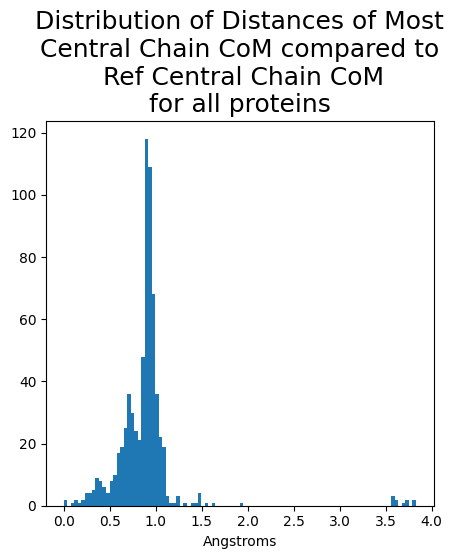

10


In [6]:
closest_CoM_lst = []
outliers = []
for lst_prots in prot_dic.values():
    for subset, prot in lst_prots.items():
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
        closest_chain = sele_closest_Chain(flatten_pdb( prot, "chain"), ref_prot_CoM )
        closest_prot_CoM = closest_chain[0].calculate_center_of_mass()
        dist = ref_prot_CoM.dist(closest_prot_CoM)
        closest_CoM_lst.append(dist)
        if dist > 2.5: outliers.append( subset )

plt.figure( figsize = (5,5))
plt.hist(closest_CoM_lst, bins = 100)
plt.title("Distribution of Distances of Most\nCentral Chain CoM compared to\n Ref Central Chain CoM\nfor all proteins", fontsize=18)
plt.xlabel("Angstroms")
plt.show()
print(len(outliers))

#### Q. Is is always the same protein chain, and protein sequence in the center? -> No

In [7]:
# Check based on protein sequence size
dic_chain_count = { "A":0, "B":0, "C":0, "Others":0 }
for lst_prots in prot_dic.values():
    for prot in lst_prots.values():
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
        closest_chain = sele_closest_Chain(flatten_pdb( prot, "chain"), ref_prot_CoM )
        print( f"Closest Chain Name: {closest_chain[0].name} | Distance to Ref Ligand CoM: {prot_CoM.dist(ref_lig_CoM)} | Distance to Ref Prot CoM: {prot_CoM.dist(ref_prot_CoM)}" )
        if closest_chain[0].name in dic_chain_count.keys():
            dic_chain_count[ closest_chain[0].name ] += 1
        else:
            dic_chain_count["Others"] += 1
print( dic_chain_count )

Closest Chain Name: A | Distance to Ref Ligand CoM: 11.573535377424447 | Distance to Ref Prot CoM: 0.6859825468652112
Closest Chain Name: A | Distance to Ref Ligand CoM: 11.353468042730402 | Distance to Ref Prot CoM: 0.9815051346651852
Closest Chain Name: C | Distance to Ref Ligand CoM: 25.879409261398543 | Distance to Ref Prot CoM: 32.0554207388259
Closest Chain Name: A | Distance to Ref Ligand CoM: 38.505388146919486 | Distance to Ref Prot CoM: 30.54361306995603
Closest Chain Name: A | Distance to Ref Ligand CoM: 11.353221518555387 | Distance to Ref Prot CoM: 0.9183541789642903
Closest Chain Name: A | Distance to Ref Ligand CoM: 11.508671583522437 | Distance to Ref Prot CoM: 0.7364156030595453
Closest Chain Name: A | Distance to Ref Ligand CoM: 11.387660281586832 | Distance to Ref Prot CoM: 0.8699799376707031
Closest Chain Name: A | Distance to Ref Ligand CoM: 12.456703127068709 | Distance to Ref Prot CoM: 0.5295173836716377
Closest Chain Name: C | Distance to Ref Ligand CoM: 25.9810

In [8]:
# Check based on protein sequence alignment
from xaidar.data.molecModels import model_seqAlign#
dic_count = { "same":0, "dif":0 }
for lst_prots in prot_dic.values():
    for prot in lst_prots.values():
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot = sele_pdb(  prot, sele_closest_Chain,  ref_prot_CoM )
        if len( flatten_pdb( prot, "chain")[0] ) != len( flatten_pdb( ref_prot, "chain")[0] ):
            print( "Dif Chain than Ref")
            dic_count["dif"] += 1
        elif not model_seqAlign( ref_prot, prot).check_match(verbose=False).match_status:
            print( "Dif Chain than Ref")            
            dic_count["dif"] += 1
        else: 
            print( "Same Chain as Ref")
            dic_count["same"] += 1
print( dic_count )


Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Same Chain as Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Dif Chain than Ref
Di

### Q. Is there a correlation between the central chain and the subset code?

In [9]:
# Check based on protein sequence size
dic_chain_count = { "A":0, "B":0, "C":0, "Others":0 }
subset_codes = {"a":[], "b":[], "c":[], "others":[] }
for dataset, lst_prots in prot_dic.items():
    for subset, prot in lst_prots.items():
        subset_index = subset[-1]
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
        closest_chain = sele_closest_Chain(flatten_pdb( prot, "chain"), ref_prot_CoM )
        if subset_index in subset_codes.keys():
            subset_codes[subset_index].append( closest_chain[0].name )
        else:
            subset_codes["others"].append( closest_chain[0].name )
        
        # print( f"Closest Chain Name: {closest_chain[0].name} | Distance to Ref Ligand CoM: {prot_CoM.dist(ref_lig_CoM)} | Distance to Ref Prot CoM: {prot_CoM.dist(ref_prot_CoM)}" )
        if closest_chain[0].name in dic_chain_count.keys():
            dic_chain_count[ closest_chain[0].name ] += 1
        else:
            dic_chain_count["Others"] += 1
    
print("{Central Chain Name:# Subsets} ------------------>", dic_chain_count )
print("{subset idx: # subsets} ------------------------->", {key:len(lst) for key,lst in subset_codes.items()} )
print("{subset idx: Set of Central Chain Names} -------->", {key:set(lst) for key,lst in subset_codes.items()} )
print("{subset idx: {Central Chain Name: # subsets } } ->", 
      { key : { chain_name_set : len( [ "_" for chain_name_unit in lst if chain_name_unit == chain_name_set ] ) 
                for chain_name_set in set(lst) } 
        for key, lst in subset_codes.items() } )
print("\nThus")

{Central Chain Name:# Subsets} ------------------> {'A': 548, 'B': 24, 'C': 114, 'Others': 0}
{subset idx: # subsets} -------------------------> {'a': 536, 'b': 145, 'c': 5, 'others': 0}
{subset idx: Set of Central Chain Names} --------> {'a': {'A', 'B'}, 'b': {'A', 'B', 'C'}, 'c': {'A', 'C'}, 'others': set()}
{subset idx: {Central Chain Name: # subsets } } -> {'a': {'A': 520, 'B': 16}, 'b': {'A': 25, 'B': 8, 'C': 112}, 'c': {'A': 3, 'C': 2}, 'others': {}}

Thus


### Q. Does the chain name always match the same protein sequence in the central protein chain? 

- No

#### Q2. What about for all protein chains? 

In [10]:
dic_chain_prots = { "A":[], "B":[], "C":[], "Others":0 }
subset_codes_prots = {'a': {'A':[], 'B':[]}, 'b': {'C':[], 'A':[], 'B':[]}, 'c': {'C':[], 'A':[]}, 'others': 0}
count = 0
for dataset, lst_prots in prot_dic.items():
    for subset, prot in lst_prots.items():
        subset_index = subset[-1]
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
        closest_chain_prot = sele_pdb( prot, sele_closest_Chain, ref_prot_CoM )
        chain_name = closest_chain_prot[0][0].name
        if chain_name in dic_chain_prots.keys():
            dic_chain_prots[chain_name].append( prot )
            subset_codes_prots[subset_index][chain_name].append( prot )
        else:
            dic_chain_prots["Others"] += 1
            subset_codes_prots["others"] += 1
        

print(dic_chain_prots["Others"])
print(subset_codes_prots["others"])
dic_chain_prots_simil = { "A": {"same":0, "dif":0}, "B":{"same":0, "dif":0}, "C":{"same":0, "dif":0},}
ref_dict = { "A":dic_chain_prots["A"][0], "B":dic_chain_prots["B"][0], "C": dic_chain_prots["C"][0],}
mismatch_observed = False
for chain_name, lst_prots in dic_chain_prots.items():
    if chain_name == "Others": continue
    for idx, prot in enumerate(lst_prots):
        if idx == 0: continue    
        if not model_seqAlign( ref_dict[chain_name], prot).check_match(verbose=False).match_status:
            # print( "Dif Chain than Ref")            
            dic_chain_prots_simil[chain_name]["dif"] += 1
            if not mismatch_observed:
                print("Different Proteins Example: ")
                model_seqAlign( ref_dict[chain_name], prot).check_match(verbose=True).visualize()
            mismatch_observed = True
        else: 
            # print( "Same Chain as Ref")
            dic_chain_prots_simil[chain_name]["same"] += 1

print(dic_chain_prots_simil)

0
0
Different Proteins Example: 
Mismatch in residue serial numbers between reference and query.
                |         |         |         |         *         |         |         |         |         +         |         |         |         |
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE
       |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||| |
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLD-E
{'A': {'same': 234, 'dif': 313}, 'B': {'same': 18, 'dif': 5}, 'C': {'same': 113, 'dif': 0}}


### Q. Is the central protein the same for each subset?

- No

In [11]:
subset_codes = {key:{"same":0, "dif":0} for key in ["a","b","c"] }
subset_seen = {key:False for key in ["a","b","c"] }
ref_subset_prot = {key: None for key in ["a","b","c"] }
mismatch_observed = False


for dataset, lst_prots in prot_dic.items():
    for subset, prot in lst_prots.items():
        subset_index = subset[-1]
        prot = clear_empty( prot )
        prot = sele_pdb( prot, sele_AA )
        prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
        closest_chain_prot = sele_pdb( prot, sele_closest_Chain, ref_prot_CoM )
        if not subset_seen[subset_index]: 
            ref_subset_prot[subset_index] = closest_chain_prot
            subset_seen[subset_index] = True
            continue

        if not model_seqAlign( ref_subset_prot[subset_index], closest_chain_prot).check_match(verbose=False).match_status:
            # print( "Dif Chain than Ref")            
            subset_codes[subset_index]["dif"] += 1
            if not mismatch_observed:
                print("Different Proteins Example: ")
                model_seqAlign( ref_subset_prot[subset_index], closest_chain_prot).check_match(verbose=True).visualize()
            mismatch_observed = True
        else: 
            # print( "Same Chain as Ref")
            subset_codes[subset_index]["same"] += 1
print(subset_codes)

Different Proteins Example: 
Mismatch in residue serial numbers between reference and query.
                |         |         |         |         *         |         |         |         |         +         |         |         |         |
Ref:   SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLDEE
       |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||| |
Query: SGAIYVGNYRVVNRHLATHNDWANLVWEDSSRDLLVSSTTAQGCDTIARCDCQTGVYYCSSRRKHYPVSFSKPSLIFVEASEYYPARYQSHLMLAVGHSEPGDCGGILRCQHGVVGIVSTGGNGLVGFADVRDLLWLD-E
{'a': {'same': 228, 'dif': 307}, 'b': {'same': 119, 'dif': 25}, 'c': {'same': 1, 'dif': 3}}


### Q. Does the central protein always have a ligand bound to it?

Get pdb of ligands that are closest to the central protein. Look at all of them in pymol, and if there is a ligand that is closer to an alternative protein rather than the central one, then this means that there are pdbs where the central protein does not have a ligand bound to it.

In [12]:
from xaidar.data.molecModels import sele_chain_name, sele_chain_idx, sele_res_idx

lst_mulit_ligs = []
lst_single_ligs = []
numb_ligs = {key:0 for key in [2,3]}
count =0
datasets = set()
for dataset, lst_prots in prot_dic.items():
    for subset, prot in lst_prots.items():
        subset_index = subset[-1]
        prot = clear_empty( prot )
        prots = sele_pdb( prot, sele_AA )

        ligs =   sele_pdb( prot, sele_Lig )
        number_of_ligs = len(flatten_pdb(ligs, "residue"))

        if number_of_ligs > 1:
            count += 1
            datasets.add(dataset)
            
            ligs = [  sele_pdb( ligs, sele_chain_idx, [idx] ) # split by chain
                     for idx in range( len(ligs[0]) ) ]
            num_chains = len(ligs)
            ligs = [  sele_pdb( lig_chain, sele_res_idx, [(res_idx, res_idx+1)], slice_within = False ) # split by residue
                    for lig_chain in ligs 
                    for res_idx in range( len( lig_chain[0][0] ) ) 
                    ]
            num_res = len(ligs)
            if num_res > num_chains: print( f"For {subset} there are several ligands in one chain")
            numb_ligs[len( ligs ) ] += 1
            if len(ligs) == 3: print(subset)

            ligs_CoM = [ flatten_pdb( lig, "chain")[0].calculate_center_of_mass() for lig in ligs ]

            central_chain_prot = sele_pdb( prots, sele_closest_Chain, ref_prot_CoM )
            central_chain_CoM = flatten_pdb( central_chain_prot, "chain")[0].calculate_center_of_mass()
            central_chain_prot_name = central_chain_prot[0][0].name

            closest_ligand, closest_ligand_dist =None, float("inf")
            for lig, lig_CoM in zip(ligs, ligs_CoM):
                lig_dist = central_chain_CoM.dist(lig_CoM)
                if lig_dist < closest_ligand_dist:
                    closest_ligand, closest_ligand_dist = lig, lig_dist

            lst_mulit_ligs.append( (subset, closest_ligand) )
        
        else: lst_single_ligs.append( (subset, ligs) )
            



print(numb_ligs)
print("Number of subsets with multiple ligands: ", count)
print("Number of datsets with multiple ligans: ", len(datasets))
print("Number of subsets with single ligands: ", len(lst_single_ligs))


For A4967a there are several ligands in one chain
A4967a
For A0501a there are several ligands in one chain
{2: 190, 3: 1}
Number of subsets with multiple ligands:  191
Number of datsets with multiple ligans:  121
Number of subsets with single ligands:  495


In [13]:
from xaidar.data.molecModels import savePDB
# print(len(lst_ligs))
# subsets, ligs = zip(*lst_mulit_ligs)
subsets, ligs = zip(*lst_single_ligs)
print(subsets)
# for subset, lig in zip(subsets, ligs): savePDB(lig, rootdir.joinpath( f"data/ev2a/fragalysis/04-closestligtocentralprot/multi_ligs/{subset}_lig.pdb") )
for subset, lig in zip(subsets, ligs):
    savePDB(lig, rootdir.joinpath( f"data/ev2a/fragalysis/04-closestligtocentralprot/single_ligs/{subset}_lig.pdb") )

('A0428a', 'A7175a', 'A5039b', 'A5460a', 'A3181a', 'A3181b', 'A0451a', 'A0586a', 'A5247b', 'A0365a', 'A5052a', 'A4980a', 'A5393a', 'A4451b', 'A3522a', 'A4316a', 'A4809a', 'A5359b', 'A5359a', 'A4509a', 'A7259a', 'A4298a', 'A1255a', 'A4644b', 'A3585a', 'A4922a', 'A0497a', 'A7465b', 'A5687a', 'A3612a', 'A4673b', 'A4812a', 'A3956a', 'A3571b', 'A4538a', 'A0375c', 'A0375a', 'A0375b', 'A4934a', 'A4519b', 'A4701a', 'A4456b', 'A5277a', 'A4669b', 'A3417a', 'A7501b', 'A5884a', 'A0853a', 'A5022b', 'A0310a', 'A3066a', 'A4403a', 'A5222a', 'A3189a', 'A3944a', 'A3218a', 'A2454a', 'A3623a', 'A3550b', 'A3550a', 'A0229a', 'A0229b', 'A4894a', 'A4319a', 'A5212a', 'A4324a', 'A4528a', 'A0514b', 'A4839a', 'A0305a', 'A1148a', 'A1148b', 'A4963b', 'A4510a', 'A4918a', 'A4847a', 'A1169a', 'A5036b', 'A3488a', 'A4694a', 'A4388a', 'A4596c', 'A0884a', 'A4786a', 'A4546a', 'A4306a', 'A3193a', 'A4029a', 'A7510b', 'A4290a', 'A4778a', 'A0526a', 'A4380a', 'A1145a', 'A1145b', 'A5213b', 'A0691a', 'A3521a', 'A3521b', 'A5091a',

In [14]:
print(rootdir.joinpath( f"data/ev2a/fragalysis/04-closestligtocentralprot"))

/dls/data2temp01/alex/xaidar/data/ev2a/fragalysis/04-closestligtocentralprot


In [15]:
get_pdb_stats(prot_dic["A0501"]["A0501a"])
ligs =   sele_pdb( ref_pdb, sele_Lig )
print(len(ligs))
get_pdb_stats(ligs)


####################
Number of models: 1
Number of chains in 1st Model: 4

Chain ID: A
	Number of Residues: 143
	Unique List of Non-A.A.: {'ZN', 'LIG'}
	Contains A.A.
Chain ID: B
	Number of Residues: 141
	Unique List of Non-A.A.: {'ZN'}
	Contains A.A.
Chain ID: C
	Number of Residues: 3
	Unique List of Non-A.A.: {'DMS'}
Chain ID: H
	Number of Residues: 15
	Unique List of Non-A.A.: {'HOH'}
1

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 1
	Unique List of Non-A.A.: {'LIG'}


In [16]:
ref_pdb[0][0].__len__() 

142

In [17]:
mobile_prot = prot_dic["A0501"]["A0501a"]
mobile_prot = sele_pdb( mobile_prot, sele_AA )
print(type(mobile_prot))
mobile_prot= sele_pdb(  mobile_prot, sele_closest_Chain,  ref_prot_CoM )
get_pdb_stats(mobile_prot)

<class 'gemmi.Structure'>

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: B
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


In [18]:
from xaidar.data.molecModels import model_seqAlign

seq = model_seqAlign( ref_prot, mobile_prot)


In [19]:
seq.check_match().match_status

Match of all residue serial numbers between reference and query.


True

## Exploring Dataset subsets with multiple chains:

### Q. For pdbs with multiple chains, is it always that the chains are different or they can be the same?

In [20]:
from xaidar.data.molecModels import sele_chain_idx
multiple_chains_subsets = [ dataset_subset for dataset_subset, count in zip(subsets_w_multiple_chains, multiple_chain_prot_count) if int(count) > 1]
dic_count = { "same":0, "dif":0 }
dif_subsets = []
for dataset, subset in multiple_chains_subsets:
    prot = prot_dic[dataset][subset]
    prot = clear_empty( prot )
    prot = sele_pdb( prot, sele_AA )
    prot_chain1 = sele_pdb( prot, sele_chain_idx, [0])
    prot_chain2 = sele_pdb( prot, sele_chain_idx, [1])
    if len( flatten_pdb( prot_chain1, "chain")[0] ) != len( flatten_pdb( prot_chain2, "chain")[0] ):
        print( "Distinct Chains within the same subset")
        dic_count["dif"] += 1
        dif_subsets.append( (dataset, subset) )
    elif not model_seqAlign( prot_chain1, prot_chain2).check_match(verbose=False).match_status:
        print( "Distinct Chains within the same subset")            
        dic_count["dif"] += 1
        dif_subsets.append( (dataset, subset) )
    else: 
        print( "Identical chains within the same subset")
        dic_count["same"] += 1

print( dic_count )



Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Distinct Chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
Identical chains within the same subset
I